In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Mahin\OneDrive\Desktop\PP\Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [6]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [7]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [8]:
df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0})

In [9]:
df["Churn_Flag"].mean() * 100

np.float64(26.536987079369588)

In [10]:
df.groupby("Contract")["Churn_Flag"].mean().sort_values(ascending=False)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_Flag, dtype: float64

In [11]:
df.groupby("tenure")["Churn_Flag"].mean().head(10)

tenure
0    0.000000
1    0.619902
2    0.516807
3    0.470000
4    0.471591
5    0.481203
6    0.363636
7    0.389313
8    0.341463
9    0.386555
Name: Churn_Flag, dtype: float64

In [12]:
df.groupby("PaymentMethod")["Churn_Flag"].mean().sort_values(ascending=False)

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn_Flag, dtype: float64

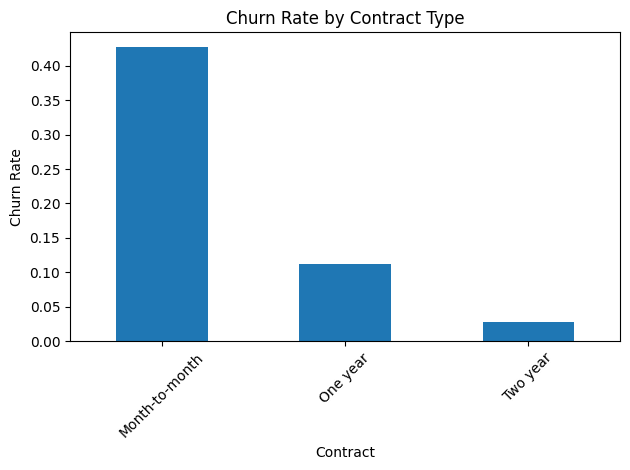

In [13]:
import matplotlib.pyplot as plt

contract_churn = df.groupby("Contract")["Churn_Flag"].mean()

contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("contract_churn.png")
plt.show()

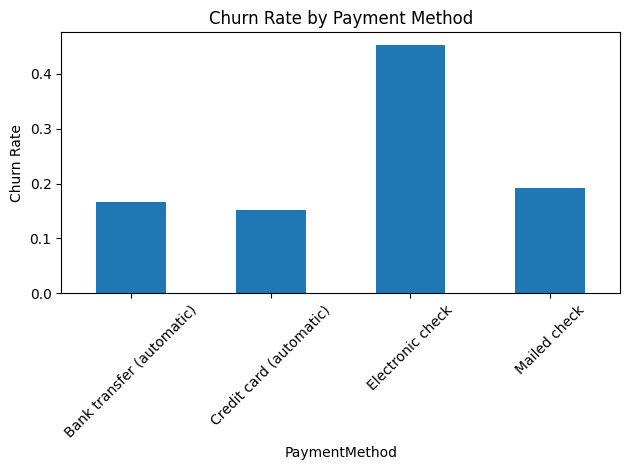

In [14]:
payment_churn = df.groupby("PaymentMethod")["Churn_Flag"].mean()

payment_churn.plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("payment_churn.png")
plt.show()

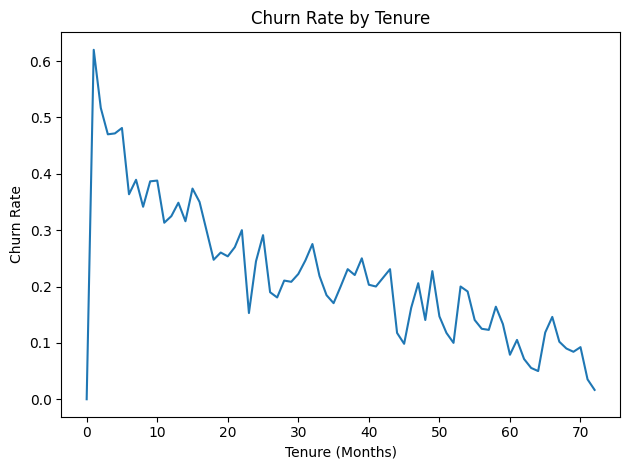

In [15]:
tenure_churn = df.groupby("tenure")["Churn_Flag"].mean()

tenure_churn.plot()
plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.savefig("tenure_churn.png")
plt.show()

In [16]:
df.to_csv("cleaned_churn_data.csv", index=False)

In [17]:
summary = df.groupby("Contract").agg(
    total_customers=("customerID", "count"),
    churned_customers=("Churn_Flag", "sum"),
    churn_rate=("Churn_Flag", "mean")
).reset_index()

summary["churn_rate"] = summary["churn_rate"] * 100

summary

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.709677
1,One year,1473,166,11.269518
2,Two year,1695,48,2.831858


In [18]:
payment_summary = df.groupby("PaymentMethod").agg(
    total_customers=("customerID", "count"),
    churned_customers=("Churn_Flag", "sum"),
    churn_rate=("Churn_Flag", "mean")
).reset_index()

payment_summary["churn_rate"] = payment_summary["churn_rate"] * 100

payment_summary

,PaymentMethod,total_customers,churned_customers,churn_rate
0,Bank transfer (automatic),1544,258,16.709845
1,Credit card (automatic),1522,232,15.243101
2,Electronic check,2365,1071,45.285412
3,Mailed check,1612,308,19.106700


Key Insight:
Month-to-month customers have the highest churn rate at approximately 42.7%, compared to 11.3% for one-year contracts and 2.8% for two-year contracts. This suggests that long-term contracts are strongly associated with customer retention.

Business Recommendation:
The company should target month-to-month customers with loyalty discounts, contract upgrade offers, and early retention campaigns during the first 3 months.